State Schema With Data Classes

### Creating State Schema Using Dataclasses

In [6]:
from typing_extensions import TypedDict
from typing import Literal 

import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

In [7]:
# Create State Type
class TypedDictState(TypedDict):
    name: str
    fruit: Literal['apple', 'banana', 'orange'] # Define a union of string literals for the 'fruit' field
    
    

In [26]:
# Create 4 functions to update the state with different fruits
def eat_fruit(state: TypedDictState):
    print('------ Eating Fruit------')
    return {'name': state['name'] + ' wants to eat fruit'}

# Createa function for each fruit
def apple(state: TypedDictState):
    print('------ Eating Apple------')
    return {'name': state['name'] + ' apple', 'fruit': 'apple'}

def banana(state: TypedDictState):
    print('------ Eating Banana------')
    return {'name': state['name'] + ' banana', 'fruit': 'banana'}

def orange(state: TypedDictState):
    print('------ Eating Orange------')
    return {'name': state['name'] + ' orange', 'fruit': 'orange'}

In [27]:
def decide_fruit(state:TypedDictState)->Literal['apple', 'banana', 'orange']:
    print('------ Deciding Fruit------')
    #return random.choice(['apple', 'banana', 'orange'])
    
    if random.random() < 0.33: # 33% chance to return 'apple'
        return 'apple'
    
    elif random.random() < 0.66: # 33% chance to return 'banana'
        return 'banana'
    
    else:
        return 'orange' # 34% chance to return 'orange'

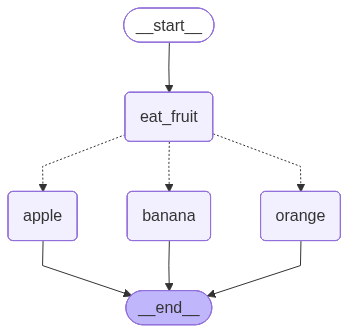

In [28]:
# Build graph

builder = StateGraph(TypedDictState)
builder.add_node('eat_fruit', eat_fruit) # 
builder.add_node('apple', apple)
builder.add_node('banana', banana)
builder.add_node('orange', orange)

# Flow of the graph
builder.add_edge(START, 'eat_fruit')
builder.add_conditional_edges('eat_fruit', decide_fruit) # Add conditional edges from 'eat_fruit' to 'apple', 'banana', and 'orange' based on the output of decide_fruit
builder.add_edge('apple', END)
builder.add_edge('banana', END)
builder.add_edge('orange', END) # Add edge from 'orange' to END

# Add 
graph = builder.compile()
# Visualize the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
# Invoke 
graph.invoke({
    'name': 'Saheed'
})

------ Eating Fruit------
------ Deciding Fruit------
------ Eating Apple------


{'name': 'Saheed wants to eat fruit apple', 'fruit': 'apple'}

### Creating State Schema Using Dataclasses

In [ ]:
# Dataclasses
from dataclasses import dataclass

@dataclass
class DataClassState:
    name:str
    fruit:Literal['apple', 'banana', 'orange']

In [34]:
# Create 4 functions to update the state with different fruits
def eat_fruit(state: DataClassState):
    print('------ Eating Fruit------')
    return {'name': state.name + ' wants to eat fruit'}

# Createa function for each fruit
def apple(state: DataClassState):
    print('------ Eating Apple------')
    return {'name': state.name + ' apple', 'fruit': 'apple'}

def banana(state: DataClassState):
    print('------ Eating Banana------')
    return {'name': state.name + ' banana', 'fruit': 'banana'}

def orange(state: DataClassState):
    print('------ Eating Orange------')
    return {'name': state.name + ' orange', 'fruit': 'orange'}

In [35]:
def decide_fruit(state:DataClassState)->Literal['apple', 'banana', 'orange']:
    print('------ Deciding Fruit------')
    #return random.choice(['apple', 'banana', 'orange'])
    
    if random.random() < 0.33: # 33% chance to return 'apple'
        return 'apple'
    
    elif random.random() < 0.66: # 33% chance to return 'banana'
        return 'banana'
    
    else:
        return 'orange' # 34% chance to return 'orange'

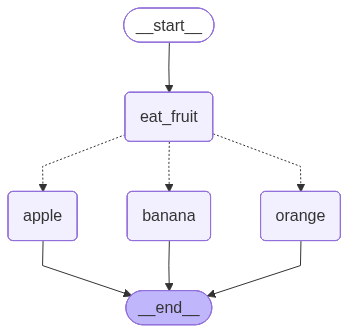

In [36]:
# Build graph

builder = StateGraph(DataClassState)
builder.add_node('eat_fruit', eat_fruit) # 
builder.add_node('apple', apple)
builder.add_node('banana', banana)
builder.add_node('orange', orange)

# Flow of the graph
builder.add_edge(START, 'eat_fruit')
builder.add_conditional_edges('eat_fruit', decide_fruit) # Add conditional edges from 'eat_fruit' to 'apple', 'banana', and 'orange' based on the output of decide_fruit
builder.add_edge('apple', END)
builder.add_edge('banana', END)
builder.add_edge('orange', END) # Add edge from 'orange' to END

# Add 
graph = builder.compile()
# Visualize the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
graph.invoke(DataClassState(name='Saheed', fruit='apple'))

------ Eating Fruit------
------ Deciding Fruit------
------ Eating Orange------


{'name': 'Saheed wants to eat fruit orange', 'fruit': 'orange'}